In [ ]:
import pandas as pd
import polars as pl
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path
import polars.selectors as cs

In [ ]:
input_folder=Path().resolve().parent /'input'
output_folder=Path().resolve().parent/'output'
output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
pl.enable_string_cache()
pl.Config.set_streaming_chunk_size(2000000)

Building customer demographics behaviour

## Importing the library defined in the working directory

In [ ]:
%%time
data=pl.scan_parquet(input_folder/'load_profile_buildingID_*')
BUILDINGS=data.collect().select(pl.col('bldg_id')).unique()


## Initial Data Preprocessing

## The aim of this section is to find as many features as possible to build accurate hypothesis

In [ ]:
%%time
Meta_data=pl.scan_parquet(input_folder/'Meta_Data.parquet').with_columns(pl.col('bldg_id').cast(pl.UInt32)).filter(
    pl.col('bldg_id').is_in(BUILDINGS.to_series().to_list())).select(pl.col('in.occupants','in.state','in.county',
                        'in.representative_income','in.area_median_income','in.income',
                        'in.income_recs_2020','in.income_recs_2015', 'in.building_america_climate_zone','in.ashrae_iecc_climate_zone_2004_sub_cz_split',
                        'in.bedrooms','in.tenure','in.household_has_tribal_persons','bldg_id')
                ).unique()

## Merging the Meta Data into the main data

In [ ]:
data=data.join(Meta_data, on="bldg_id")

## Getting the columns of the data to use to build the data dictionary

In [ ]:
schema=data.collect_schema().names()

## Prepare the data dictionary based on the existing columns

In [ ]:
df_dictionary=pl.read_csv(input_folder/"data_dictionary.tsv", separator='\t').filter(pl.col('field_name').is_in(schema))

In [ ]:
df_dictionary.write_csv(output_folder/'data_dictionary.csv')

In [ ]:
## Data Reduction

In [ ]:
LONG_DURATION=['out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh']

In [ ]:
df=data.rename({'in.ashrae_iecc_climate_zone_2004_sub_cz_split': 'climatezone',
                'out.electricity.cooling.energy_consumption..kwh': 'out.electricity.AC.energy_consumption..kwh'}).with_columns(
            pl.col('timestamp').dt.weekday().alias('day of the week'),
            pl.col('timestamp').dt.hour().alias('hour of the day'),
            pl.col('timestamp').dt.day().alias('day of the month'),
            pl.col('timestamp').dt.ordinal_day().alias('day of the year'),
            pl.col('timestamp').dt.week().alias('week of the year'),
            pl.col('timestamp').dt.month().alias('month of the year'),
            pl.col('timestamp').dt.quarter().alias('quarter')).with_columns(
            pl.when(pl.col('day of the week').is_in([6,7])).then(1).otherwise(0).alias('IsWeekend')
            ).select(cs.matches('^out.electricity.*|^out.site_energy.*|^bldg*|^day*|^hour*|^week*|^month*|^time*|^quarter|^IsWeekend|^in.*|^Short|^climatezone$')).collect()

In [ ]:
INTENSITY_COLS=df.select(cs.ends_with('energy_consumption_intensity..kwh_per_ft2')).columns

In [123]:
SHORT_DURATION=df.select(
    cs.float().exclude('in.sqft','in.representative_income',
                           'out.site_energy.total.energy_consumption..kwh',
                           'out.site_energy.net.energy_consumption..kwh').exclude(*LONG_DURATION).exclude(*INTENSITY_COLS)).columns

In [137]:
import importlib
import lib
importlib.reload(lib)
vis=lib.loadProfile(df)

* Checking missing values

In [138]:
df.null_count()

bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.AC.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,out.electricity.freezer.energy_consumption..kwh,out.electricity.heating.energy_consumption..kwh,out.electricity.heating_fans_pumps.energy_consumption..kwh,out.electricity.heating_hp_bkup.energy_consumption..kwh,out.electricity.heating_hp_bkup_fa.energy_consumption..kwh,out.electricity.hot_water.energy_consumption..kwh,out.electricity.hot_water_solar_th.energy_consumption..kwh,out.electricity.lighting_exterior.energy_consumption..kwh,out.electricity.lighting_garage.energy_consumption..kwh,out.electricity.lighting_interior.energy_consumption..kwh,out.electricity.mech_vent.energy_consumption..kwh,out.electricity.net.energy_consumption..kwh,out.electricity.permanent_spa_heat.energy_consumption..kwh,out.electricity.permanent_spa_pump.energy_consumption..kwh,out.electricity.plug_loads.energy_consumption..kwh,out.electricity.pool_heater.energy_consumption..kwh,out.electricity.pool_pump.energy_consumption..kwh,out.electricity.pv.energy_consumption..kwh,out.electricity.range_oven.energy_consumption..kwh,out.electricity.refrigerator.energy_consumption..kwh,out.electricity.television.energy_consumption..kwh,out.electricity.total.energy_consumption..kwh,out.electricity.well_pump.energy_consumption..kwh,out.site_energy.net.energy_consumption..kwh,out.site_energy.total.energy_consumption..kwh,out.electricity.ceiling_fan.energy_consumption_intensity..kwh_per_ft2,out.electricity.clothes_dryer.energy_consumption_intensity..kwh_per_ft2,…,out.electricity.lighting_interior.energy_consumption_intensity..kwh_per_ft2,out.electricity.mech_vent.energy_consumption_intensity..kwh_per_ft2,out.electricity.net.energy_consumption_intensity..kwh_per_ft2,out.electricity.permanent_spa_heat.energy_consumption_intensity..kwh_per_ft2,out.electricity.permanent_spa_pump.energy_consumption_intensity..kwh_per_ft2,out.electricity.plug_loads.energy_consumption_intensity..kwh_per_ft2,out.electricity.pool_heater.energy_consumption_intensity..kwh_per_ft2,out.electricity.pool_pump.energy_consumption_intensity..kwh_per_ft2,out.electricity.pv.energy_consumption_intensity..kwh_per_ft2,out.electricity.range_oven.energy_consumption_intensity..kwh_per_ft2,out.electricity.refrigerator.energy_consumption_intensity..kwh_per_ft2,out.electricity.television.energy_consumption_intensity..kwh_per_ft2,out.electricity.total.energy_consumption_intensity..kwh_per_ft2,out.electricity.well_pump.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.occupants,in.state,in.county,in.representative_income,in.area_median_income,in.income,in.income_recs_2020,in.income_recs_2015,in.building_america_climate_zone,climatezone,in.bedrooms,in.tenure,in.household_has_tribal_persons,day of the week,hour of the day,day of the month,day of the year,week of the year,month of the year,quarter,IsWeekend
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35040,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


No missing values within the data

In [ ]:
# TODO: Do some visualizations to detect outlier--might include from the one below
# TODO: Do data transformation then and see the resulted output and measure the difference between both
# TODO: Data integration is already included
# TODO: Data reduction might be considered by doing something like PCA

## End of data preprocessing

In [ ]:
# Run boxplots
vis.boxplot_exp()

In [ ]:
# Run histograms
vis.hist_exp()

In [ ]:
# Run Boxen plot for large distributions
vis.boxen_exp()

### Now we want to see the total amount spent if its holiday or not

In [ ]:
vis.barplot_seaborn('out.electricity.total.energy_consumption..kwh', 'IsWeekend')

In [ ]:
df.head(10)

## Visualization of the long duration appliances usage

Long duration appliances are water heaters, refrigerators, Gas Stove

## First Hypothesis

the energy consumption patterns is significantly determined by the temporal attributes

In [ ]:
## TODO: Some hypotheses should be made to visulize the relationship of between divices consumption with the time pattern

### Sub Hypothesis 1: the hour of the day singificantly impact the consumption pattern of long duration appliances

In [ ]:
long_duration_hr=df.select('hour of the day', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('hour of the day').agg(pl.all().sum()).sort('hour of the day')

In [ ]:
vis.display_totals(long_duration_hr,'out.electricity.total', 'hour of the day')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_hr, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_hr,'hour of the day', 'out.electricity.AC')

In [ ]:
vis._barplot_seaborn(long_duration_hr, 'hour of the day', 'out.electricity.AC')

# Discussion
As seen in the previous plot AC usage increases towards the mid of the day and starts plummeting towards later nights

## we Found that the ac correlates more to the values to the total consumption of energy

In [ ]:
vis.long_dev_temporal_based(long_duration_hr, 'hour of the day')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_hr, 'hour of the day')

# Dicussion
The p-value for the correlation between all appliances and total consumption with the hour of the day is all less then 0.05
Indicating a strong correlation, therefore we reject the null hypothesis and we accept the alternative
therefore, hour of the day significantly determines the consumption patterns

Refrigerator has shown the highest correlation with the hour of the day column

In [ ]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.refrigerator")

In [ ]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.refrigerator")

The second strongly correlated appliance is television as people to have thier tvs on in the end of the night

In [ ]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.television")

In [ ]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.television")

____________

### Sub hypothesis 2: the day of the month singificantly impact the consumption pattern

In [ ]:
long_duration_dm=df.select('day of the month', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('day of the month').agg(pl.all().sum()).sort('day of the month')

In [ ]:
vis.display_totals(long_duration_dm,'day of the month','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_dm, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_dm,'day of the month','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_dm, 'day of the month')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_dm, 'day of the month')

In [ ]:
## TODO: Find the answer of the relationship between the day of the month and the heating appliance

## Discussion
there is a weird relationship between the heating and the day of the month which needs to be answered in this section

In [ ]:
vis.display_totals(long_duration_dm, 'day of the month',"out.electricity.heating")

In [ ]:
vis._barplot_seaborn(long_duration_dm,'day of the month',"out.electricity.heating")

### Sub Hypothesis 3: the week of the year singificantly impact the consumption pattern

In [ ]:
long_duration_week=df.select('week of the year', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('week of the year').agg(pl.all().sum()).sort('week of the year')

In [ ]:
vis.display_totals(long_duration_week, 'week of the year','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_week, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_week, 'week of the year','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_week,'week of the year')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_week, 'week of the year')

## Discussion
television is mostly correlated with the weeks of the year which is also weird
let see visualization for that

In [ ]:
vis.display_totals(long_duration_week, 'week of the year',"out.electricity.television")

In [ ]:
vis._barplot_seaborn(long_duration_week,'week of the year',"out.electricity.television")

### Sub Hypothesis 4: the month of the year singificantly impact the consumption pattern

In [ ]:
long_duration_m=df.select('month of the year', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('month of the year').agg(pl.all().sum()).sort('month of the year')

In [ ]:
vis.display_totals(long_duration_m,'month of the year','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_m, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_m,'month of the year','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_m, 'month of the year')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_m, 'month of the year')

## Discussion
heating is mostly correlated with the months of the year which is also weird
let see visualization for that

In [ ]:
vis.display_totals(long_duration_m, 'month of the year',"out.electricity.heating")

In [ ]:
vis._barplot_seaborn(long_duration_m,'month of the year',"out.electricity.heating")

### Sub Hypothesis 5: the season of the year singificantly impact the consumption pattern

In [ ]:
long_duration_m=df.select('quarter', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('quarter').agg(pl.all().sum()).sort('quarter')

In [ ]:
vis.display_totals(long_duration_m,'quarter','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_m, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_m,'quarter','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_m, 'quarter')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_m, 'quarter')

## Discussion
heating is mostly correlated with the months of the year which is also weird
let see visualization for that

In [ ]:
vis.display_totals(long_duration_m, 'quarter',"out.electricity.heating")

In [ ]:
vis._barplot_seaborn(long_duration_m,'quarter',"out.electricity.heating")

## Second Hypothesis

<b> a specific subset of applainces determines the peak load period,which varies systematically by climate zone and season

# determining peak load periods --

### Distribution of site and total energy consumption monthly

In [ ]:
initial_peak=df.select(pl.col('out.electricity.total.energy_consumption..kwh','out.site_energy.total.energy_consumption..kwh','month of the year')
                 ).pipe(vis.edit_column_names).group_by('month of the year').agg(pl.all().sum())
vis.lineplot(initial_peak,'month of the year',['out.electricity.total','out.site_energy.total'])

The reason for the site energy consumption to be more than the total site energy consumption is because the site energy includes other usage and factors such as propane and gas. Total energy consumption is only collected and consumed from the appliances.

In order to make sure that the difference is the for the propoane and gas lets apply the following calculation

Checking if manually calculating the devices consumption will result in the same computation restulted in the first place

Site totals contain extra information regarding the propane gas and fuel oil, unlike the total consumption that only contains the totals of each appliance usage and doesn't related to other factors

## We determine the specific day for which the peak was there showing the distribution of all devices in that specific day

First determine the month that has the highest peak

In [ ]:
vis._barplot_seaborn(initial_peak, 'month of the year', 'out.electricity.total')

Ok now the month of the peak was septemper now lets detect the exact day

visualization for the day of the month

In [ ]:
peak_load=df.filter(pl.col('month of the year')==9).select(*LONG_DURATION, 'day of the month').pipe(vis.edit_column_names).group_by('day of the month').agg(
    pl.all().sum())
defined_columns=peak_load.columns
defined_columns.remove('day of the month')
vis.lineplot(peak_load, 'day of the month',defined_columns)

identify the day with major load

In [ ]:
vis._barplot_seaborn(peak_load, 'day of the month', 'out.electricity.total')

the major day is identified as 6th of the September

In [ ]:
peak_load_hr=df.filter(pl.col('month of the year')==9, pl.col('day of the month')==16).select(
    cs.matches('^out.electricity.*|^out.site_energy.*'),
    'hour of the day').select(*LONG_DURATION, 'hour of the day').pipe(vis.edit_column_names).group_by('hour of the day').agg(
    pl.all().sum())
defined_columns=peak_load_hr.columns
defined_columns.remove('hour of the day')
vis.lineplot(peak_load_hr, 'hour of the day',defined_columns)

identify the day with major load

In [ ]:
vis._barplot_seaborn(peak_load_hr, 'hour of the day', 'out.electricity.total')

The peak hour is identified as 16 September at 3: PM 

Now we need to see at that specific time, the site total consumption amount

In [ ]:
table=peak_load_hr.unpivot(cs.float(), index="hour of the day", variable_name="Appliances", value_name="usage").filter(
pl.col("hour of the day")==16).with_columns(pl.col('Appliances').str.strip_prefix('out.electricity.'))
vis._barplot_seaborn(table, "Appliances","usage")

### Lets measure the impact of climate zone on the distribution

#### month of the year

In [ ]:
peak_load_zone_m=df.select(
    *LONG_DURATION, 'month of the year','climatezone').pipe(vis.edit_column_names).group_by('month of the year','climatezone').agg(
    pl.all().exclude('climatezone').sum())
load_zone_melted=peak_load_zone_m.unpivot(cs.float(), index=['month of the year','climatezone'], variable_name="Appliances", value_name="usage").with_columns(
pl.col('Appliances').str.strip_prefix('out.electricity'))
vis.replot_zone(load_zone_melted, 'month of the year', 'usage','Appliances','climatezone')

In [ ]:
vis._barplot_seaborn(peak_load_zone_m, 'month of the year', 'out.electricity.total', 'climatezone')

#### day of the month

In [ ]:
peak_load_zone_d=df.filter(pl.col('month of the year')==9).select(
    *LONG_DURATION, 'day of the month','climatezone').pipe(vis.edit_column_names).group_by('day of the month','climatezone').agg(
    pl.all().exclude('climatezone').sum())
load_zone_melted=peak_load_zone_d.unpivot(cs.float(), index=['day of the month','climatezone'], variable_name="Appliances", value_name="usage").with_columns(
pl.col('Appliances').str.strip_prefix('out.electricity'))
vis.replot_zone(load_zone_melted, 'day of the month', 'usage','Appliances','climatezone')

In [ ]:
vis._barplot_seaborn(peak_load_zone_d, 'day of the month', 'out.electricity.total', 'climatezone')

#### hour of the day

In [ ]:
peak_load_zone_h=df.filter(pl.col('month of the year')==9, pl.col('day of the month')==16).select(
    *LONG_DURATION, 'hour of the day','climatezone').pipe(vis.edit_column_names).group_by('hour of the day','climatezone').agg(
    pl.all().exclude('climatezone').sum())
load_zone_melted=peak_load_zone_h.unpivot(cs.float(), index=['hour of the day','climatezone'], variable_name="Appliances", value_name="usage").with_columns(
pl.col('Appliances').str.strip_prefix('out.electricity'))
vis.replot_zone(load_zone_melted, 'hour of the day', 'usage','Appliances','climatezone')

In [ ]:
vis._barplot_seaborn(peak_load_zone_h, 'hour of the day', 'out.electricity.total', 'climatezone')

In [ ]:
table=peak_load_zone_h.unpivot(cs.float(), index=["hour of the day","climatezone"], variable_name="Appliances", value_name="usage").filter(
pl.col("hour of the day")==16).with_columns(pl.col('Appliances').str.strip_prefix('out.electricity.'))
vis._barplot_seaborn(table, "Appliances","usage","climatezone")

## Third Hypothesis

Appliances exhibit a correlated consumption pattern, combination of appliances functioning simultanously occurs more often than a random choice

in This Hypothesis we are estimating a relationship between the appliances themselves and that their operation is not random

In [ ]:
Appliances=df.group_by('bldg_id','timestamp').agg(pl.sum_horizontal(*SHORT_DURATION).alias('Short Duration Comulative'),
                                       pl.all()).explode(pl.all().exclude('bldg_id','timestamp')
                                                        ).select(*LONG_DURATION, * SHORT_DURATION,
                                                                 'hour of the day','day of the month','month of the year','quarter','climatezone','Short Duration Comulative')

In [ ]:
# pair plot for all appliances grouped by the climate zone
targets=LONG_DURATION + ['Short Duration Comulative']
appl_rel=Appliances.select(*targets,'month of the year', 'climatezone').group_by('month of the year','climatezone').agg(pl.all().sum()).select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
plt.figure(figsize=(20,7))
vis.pairplot(appl_rel.to_pandas(),'climatezone')

#### now we will make correlation matrix to see if there is a relationship between appliances

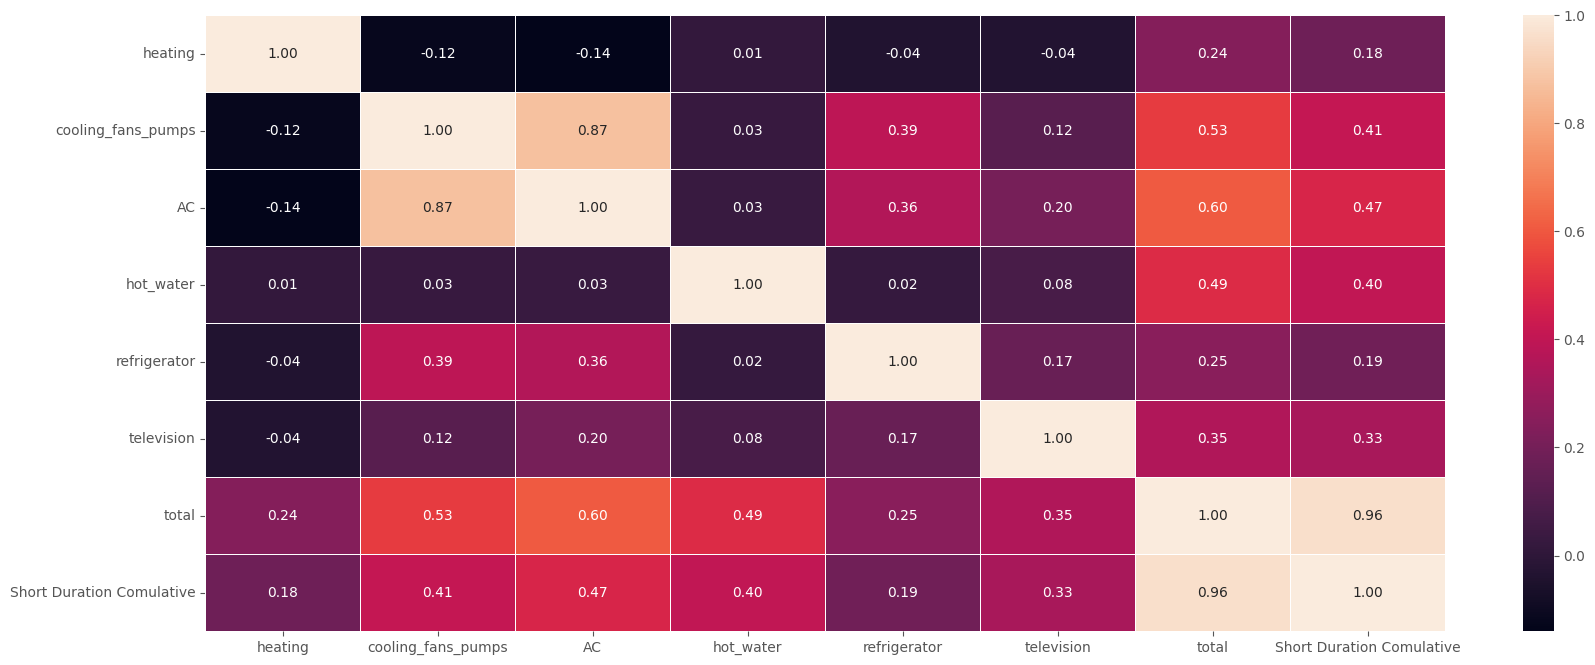

In [139]:
correlation=Appliances.select(*targets).corr().select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(correlation, correlation.columns)

In [131]:
correlation

heating,cooling_fans_pumps,AC,hot_water,refrigerator,television,total,Short Duration Comulative
f64,f64,f64,f64,f64,f64,f64,f64
1.0,-0.120214,-0.139818,0.012328,-0.040954,-0.036854,0.239669,0.181886
-0.120214,1.0,0.873447,0.026931,0.392107,0.121202,0.534807,0.410025
-0.139818,0.873447,1.0,0.033088,0.363284,0.204862,0.604386,0.471496
0.012328,0.026931,0.033088,1.0,0.022484,0.076161,0.490997,0.399612
-0.040954,0.392107,0.363284,0.022484,1.0,0.165289,0.254487,0.189194
-0.036854,0.121202,0.204862,0.076161,0.165289,1.0,0.354776,0.33494
0.239669,0.534807,0.604386,0.490997,0.254487,0.354776,1.0,0.962939
0.181886,0.410025,0.471496,0.399612,0.189194,0.33494,0.962939,1.0


In [ ]:
# Visualization of the heatmap

In [ ]:
##TODO: Make a pairplot for all long duration appliances generally
## TODO: Make a pairplot for all long duration appliances using correlations like is_Holiday
sns.pairplot(data=Appliances.to_pandas())

This proves hypothesis four that there is a relationship between devices

## Fourth Hypothesis

User Behaviour analysis